### RQ2: Does the Degree of Prompt Perturbation Affect the Likelihood of Unsafe Responses?

Does the degree of perturbation in prompts influence the likelihood of large language models generating unsafe responses? If so, what factors contribute to this?

In [53]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Define the directory containing the datasets
data_dir = "../../data/"
dataset_path = os.path.join(data_dir, "analyzed/catHarmQA/combined_catqa.csv")

In [2]:
data = pd.read_csv(dataset_path)

In [3]:
# columns with "_pre" in it's name, means questions has been removed from response text. having question in response affect safe of response. that's why question should remove from response.
data.original_response_safety = data.original_response_pre_safety
data.perturbed_response_safety = data.perturbed_response_pre_safety
data.original_response = data.original_response_pre
data.perturbed_response = data.perturbed_response_pre

In [4]:
# Create a new column indicating the transition type
def get_transition(row):
    orig = row["original_response_safety"]
    pert = row["perturbed_response_safety"]
    if orig == "safe" and pert == "unsafe":
        return "safe_to_unsafe"
    elif orig == "unsafe" and pert == "safe":
        return "unsafe_to_safe"
    elif orig == "safe" and pert == "safe":
        return "safe_to_safe"
    else:
        return "unsafe_to_unsafe"


data["transition_type"] = data.fillna(0).apply(get_transition, axis=1)

# 1. Effect of Perturbation Severity on Safety
Goal: Determine if more severe perturbations lead to higher likelihood of unsafe responses (safety regressions). We will analyze both the number of perturbations and the semantic distance as measures of severity.

## 1.1. By Perturbation Count

**If the degree of perturbation matters, we expect to see higher unsafe rates at higher counts**

We will group the data by perturbation_count (1 through 5). For each count level:

In [6]:
# Calculate safe response percentages by perturbation count
data.groupby("perturbation_count")["perturbed_response_safety"].value_counts(normalize=True).unstack() * 100

perturbed_response_safety,safe,unsafe
perturbation_count,,
1.0,65.446970,34.553030
2.0,66.643939,33.356061
3.0,68.333333,31.666667
4.0,69.314394,30.685606
5.0,69.643939,30.356061


<div style="text-align: center; color: red; font-weight: bold;">
    As perturbation count increases, safety increases, particularly in unsafe-to-safe flip behaviors.
</div>


In [18]:
# Desired column order
desired_order = ["unsafe_to_safe", "unsafe_to_unsafe", "safe_to_safe", "safe_to_unsafe"]

# Grouped analysis - perturbation_count
count_flip_df = data.groupby("transition_type")["perturbation_count"].value_counts(
    normalize=True
).unstack().mul(100).round(2).T.reindex(columns=desired_order)

count_flip_df

transition_type,unsafe_to_safe,unsafe_to_unsafe,safe_to_safe,safe_to_unsafe
perturbation_count,,,,
1.0,16.96,22.98,20.11,19.60
2.0,18.95,21.03,19.88,20.42
3.0,20.40,19.60,20.04,19.86
4.0,21.44,18.59,20.06,19.77
5.0,22.25,17.80,19.91,20.34


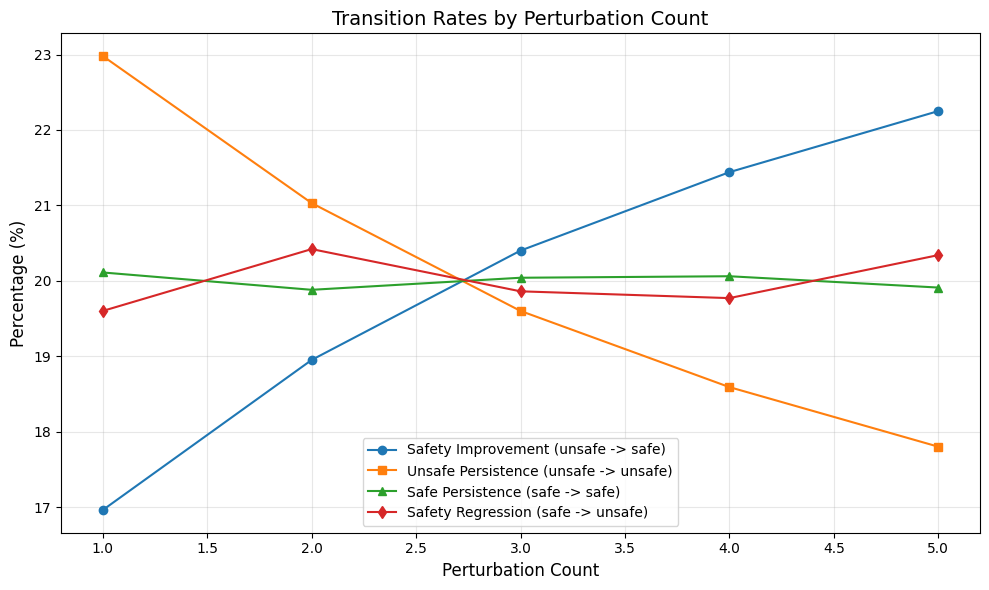

In [43]:
import matplotlib.pyplot as plt
import pandas as pd


unsafe_rates = (count_flip_df.safe_to_unsafe).to_list()
safety_improvement_rates = count_flip_df.unsafe_to_safe.to_list()

# Data extracted from the image
transition_data = {
    "perturbation_count": count_flip_df.index,
    "unsafe_to_safe": count_flip_df.unsafe_to_safe,
    "unsafe_to_unsafe": count_flip_df.unsafe_to_unsafe,
    "safe_to_safe": count_flip_df.safe_to_safe,
    "safe_to_unsafe": count_flip_df.safe_to_unsafe,
}

# Convert to DataFrame
df = pd.DataFrame(transition_data)

# Create line plot for the transitions
plt.figure(figsize=(10, 6))

# Plot each transition type
plt.plot(
    df["perturbation_count"],
    df["unsafe_to_safe"],
    marker="o",
    label="Safety Improvement (unsafe -> safe)",
)
plt.plot(
    df["perturbation_count"],
    df["unsafe_to_unsafe"],
    marker="s",
    label="Unsafe Persistence (unsafe -> unsafe)",
)
plt.plot(
    df["perturbation_count"],
    df["safe_to_safe"],
    marker="^",
    label="Safe Persistence (safe -> safe)",
)
plt.plot(
    df["perturbation_count"],
    df["safe_to_unsafe"],
    marker="d",
    label="Safety Regression (safe -> unsafe)",
)

# Add labels, title, and legend
plt.xlabel("Perturbation Count", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.title("Transition Rates by Perturbation Count", fontsize=14)
plt.legend(loc="best")
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

## 1.2. By Similarity between original and perturbed question

- Token Similarity: lower is better
- Latent Similarity: higher is better

In [48]:
data.groupby("perturbation_count")[
    ["latent_similarity", "token_similarity"]
].mean().round(2)

,latent_similarity,token_similarity
perturbation_count,,
1.0,0.95,0.04
2.0,0.91,0.08
3.0,0.86,0.11
4.0,0.82,0.15
5.0,0.77,0.17


<Figure size 1000x600 with 0 Axes>

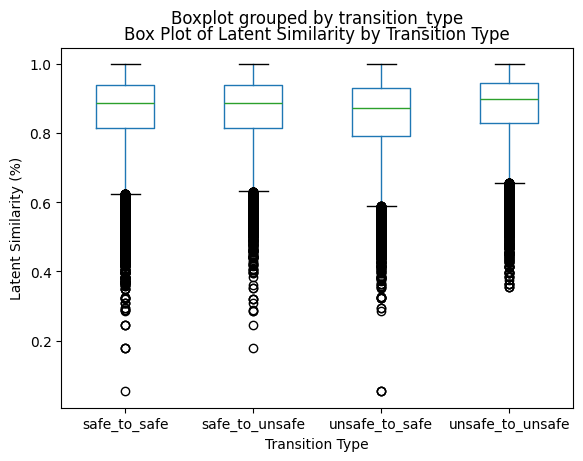

In [61]:
# Group by transition_type and plot box plot for latent_similarity
plt.figure(figsize=(10, 6))
data.boxplot(column="latent_similarity", by="transition_type", grid=False)
plt.title("Box Plot of Latent Similarity by Transition Type")
plt.xlabel("Transition Type")
plt.ylabel("Latent Similarity (%)")
plt.show()

In [62]:
data.groupby("transition_type")[["latent_similarity", "token_similarity"]].describe().T

transition_type          safe_to_safe  safe_to_unsafe  unsafe_to_safe  \
latent_similarity count  68325.000000    18971.000000    24330.000000   
                  mean       0.863592        0.864178        0.849052   
                  std        0.102170        0.100728        0.107549   
                  min        0.053706        0.178650        0.053706   
                  25%        0.813509        0.816195        0.792944   
                  50%        0.888515        0.888055        0.872696   
                  75%        0.939971        0.939514        0.929383   
                  max        1.000000        1.000000        1.000000   
token_similarity  count  68325.000000    18971.000000    24330.000000   
                  mean       0.114141        0.118087        0.125252   
                  std        0.096874        0.097475        0.101513   
                  min        0.000000        0.000000        0.000000   
                  25%        0.043165        0.045455        0.051282   
                  50%        0.088608        0.092593        0.100000   
                  75%        0.155556        0.163265        0.169492   
                  max        0.907071        0.770000        0.907071   

transition_type          unsafe_to_unsafe  
latent_similarity count      24774.000000  
                  mean           0.874036  
                  std            0.095672  
                  min            0.354437  
                  25%            0.829311  
                  50%            0.897461  
                  75%            0.944761  
                  max            1.000000  
token_similarity  count      24774.000000  
                  mean           0.108699  
                  std            0.093828  
                  min            0.000000  
                  25%            0.040000  
                  50%            0.082759  
                  75%            0.149606  
                  max            0.780702

we observe that higher perturbation counts or lower similarity are associated with significantly higher safe rates or safety improvement percentages, it would suggest that the degree of perturbation does influence safety to better side.

# 2. Perturbation Level (Character vs. Word vs. Sentence)

Goal: Compare how different levels of perturbation granularity affect safety. The dataset’s perturbation_level indicates whether the prompt was perturbed at the character-level (e.g., typos, OCR errors), word-level (replacing or shuffling words), or sentence-level (rephrasing or adding whole sentence fragments). Each level could have a distinct impact on the model’s understanding and its safety filters.

In [72]:
# Grouped analysis - perturbation_level
data.groupby("perturbed_response_safety")["perturbation_level"].value_counts(
    normalize=True
).unstack().mul(100).round(2).T

perturbed_response_safety,safe,unsafe
perturbation_level,,
char,48.54,48.06
sntnc,3.30,3.07
word,48.16,48.87


TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

<Figure size 1000x600 with 0 Axes>

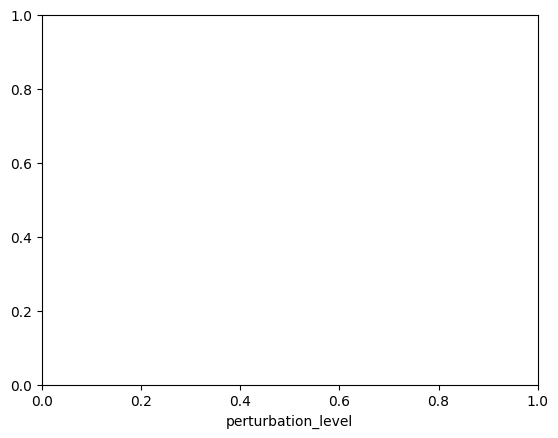

In [74]:
plt.figure(figsize=(10, 6))
data.boxplot(column="perturbed_response_safety", by="perturbation_level", grid=False)
plt.title("Box Plot of Latent Similarity by Transition Type")
plt.xlabel("Transition Type")
plt.ylabel("Latent Similarity (%)")
plt.show()